In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
import sys
from packaging import version
import sklearn

# Check Python version
if sys.version_info < (3, 7):
    raise ValueError(f"Python version must be 3.7 or higher. Found: {sys.version_info.major}.{sys.version_info.minor}")

# Check Scikit-learn version
if version.parse(sklearn.__version__) < version.parse("1.0.1"):
    raise ValueError(f"Scikit-learn version must be 1.0.1 or higher. Found: {sklearn.__version__}")

print("Environment checks passed: Python and Scikit-learn versions meet requirements.")

Environment checks passed: Python and Scikit-learn versions meet requirements.


In [3]:
from pathlib import Path  # Importing the Path class from the pathlib module to handle file system paths
import pandas as pd  # Importing pandas as pd for data manipulation and analysis
import tarfile  # Importing the tarfile module to work with tar archive files
import urllib.request  # Importing urllib.request to handle URL operations

def load_housing_data():
    # Define the path to the tarball file
    tarball_path = Path("datasets/housing.tgz")

    # Check if the tarball file already exists
    if not tarball_path.is_file():
        # Create the datasets directory if it does not exist
        Path("datasets").mkdir(parents=True, exist_ok=True)

        # URL where the dataset is located
        url = "https://github.com/ageron/data/raw/main/housing.tgz"

        # Download the tarball file from the URL to the specified path
        urllib.request.urlretrieve(url, tarball_path)

        # Open the tarball file
        with tarfile.open(tarball_path) as housing_tarball:
            # Extract all files from the tarball to the datasets directory
            # Added filter='data' to address DeprecationWarning in Python 3.14+
            housing_tarball.extractall(path="datasets", filter='data')


    ##### Here is our main activity ######
    # Load the housing.csv file into a pandas DataFrame and return it
    return pd.read_csv(Path("datasets/housing/housing.csv"))

# Call the function to load the housing data into a DataFrame
housing = load_housing_data()
print("Housing data loaded successfully.")

Housing data loaded successfully.


In [4]:
# Display the first five rows of the housing DataFrame to get an initial overview of the data
housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#Stratified Sampling

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# Ensure the housing DataFrame has a default integer index
# This is crucial because StratifiedShuffleSplit generates integer indices
# which are expected to align with a RangeIndex for .loc[]
if not isinstance(housing.index, pd.RangeIndex):
    housing.reset_index(drop=True, inplace=True)

# Create income categories for stratified sampling
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

# Stratified Split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

# Remove income_cat so the data is back to its original state
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# Separate predictors and labels (This part is commented out as it was likely causing issues later on, and there are other cells that perform this separation)
# housing = strat_train_set.drop("median_house_value", axis=1)
# housing_labels = strat_train_set["median_house_value"].copy()

#Preprocessing Pipeline with ColumnTransformer

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define numeric and categorical columns based on `strat_train_set`.
# `num_attribs` should contain all numerical features, excluding the target (`median_house_value`)
# and the categorical feature (`ocean_proximity`). `income_cat` has already been dropped from `strat_train_set`.
numerical_features = strat_train_set.select_dtypes(include=np.number).columns.tolist()
if "median_house_value" in numerical_features:
    numerical_features.remove("median_house_value")
num_attribs = numerical_features

cat_attribs = ["ocean_proximity"]

# Numerical Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler()),
])

# Full Column Transformer (Note: This `full_pipeline` and `housing_prepared` are not used for model training later on in the notebook.)
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

# The original line `housing_prepared = full_pipeline.fit_transform(housing)` used the global `housing` DataFrame.
# As `housing_prepared` is not used subsequently and the `num_attribs` are now derived from `strat_train_set`,
# this line is removed to avoid potential inconsistencies and for clarity.
# If `housing_prepared` were needed, the `housing` DataFrame would also need appropriate preprocessing for its columns.


**Standard Scaling**

In [7]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

# Define strat_housing_num from strat_train_set using the previously defined num_attribs
strat_housing_num = strat_train_set[num_attribs]

strat_housing_num_std_scaled = std_scaler.fit_transform(strat_housing_num)

In [8]:

from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer

# Define a function to compute the ratio of the first column to the second column
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

# Define a function to name the ratio feature
def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

# Custom Transformer: ClusterSimilarity
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

# Create a pipeline to compute the ratio, impute missing values, and standardize the result
def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"), # Impute missing values with the median
        FunctionTransformer(column_ratio, feature_names_out=ratio_name), # Compute ratio
        StandardScaler()) # Standardize the ratio

# Create a pipeline to apply logarithmic transformation, impute missing values, and standardize the result
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"), # Impute missing values with the median
    FunctionTransformer(np.log, feature_names_out="one-to-one"), # Apply logarithmic transformation
    StandardScaler()) # Standardize the transformed features

# Instantiate the ClusterSimilarity transformer for geographical similarity computation
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

# Create a default numerical pipeline for imputation and standardization
def default_num_pipeline():
    return make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())

# Define cat_pipeline
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

# Combine all pipelines using ColumnTransformer to apply different preprocessing steps to different subsets of features
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]), # Ratio of bedrooms to rooms
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]), # Ratio of rooms per household
        ("people_per_house", ratio_pipeline(), ["population", "households"]), # Ratio of people per household
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]), # Log transformation
        ("geo", cluster_simil, ["latitude", "longitude"]),   # Geographical similarity
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),  # Categorical features
    ],
    # Apply default numerical pipeline to remaining columns (e.g., housing_median_age)
    remainder=default_num_pipeline())  # one column remaining: housing_median_age

Let's apply the preprocessing pipeline to the housing DataFrame

In [9]:
strat_housing_prepared = preprocessing.fit_transform(strat_train_set)
strat_housing_prepared.shape

(16512, 25)

In [10]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age', 'remainder__median_house_value'],
      dtype=object)

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Separate features (strat_housing) and labels (strat_housing_labels) from strat_train_set
# This is crucial because the 'preprocessing' pipeline is applied to the features (X)
# and the 'lin_reg' model is fitted with these transformed features and the target labels (y).
strat_housing = strat_train_set.drop("median_house_value", axis=1)
strat_housing_labels = strat_train_set["median_house_value"].copy()

# Create a Linear Regression model instance
# The 'preprocessing' pipeline will first transform the input features
lin_reg = make_pipeline(preprocessing, LinearRegression())

# Fit the Linear Regression model using the preprocessed training features and corresponding labels
lin_reg.fit(strat_housing, strat_housing_labels)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Here we use the trained linear regression model to make predictions on the training dataset (strat_housing)

In [12]:
# Use the trained Linear Regression model to make predictions on the training dataset
strat_housing_predictions = lin_reg.predict(strat_housing)

# Display the first five predictions, rounded to the nearest hundred
strat_housing_predictions[:5].round(-2)  # -2 = rounded to the nearest hundred

array([242800., 375900., 127500.,  99400., 324600.])

Compare against the actual values:

In [13]:
strat_housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

Lets compute the error ratio

In [14]:
# computes the error ratios discussed in the book
error_ratios = strat_housing_predictions[:5].round(-2) / strat_housing_labels.iloc[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-47.0%, -22.3%, 25.4%, 3.4%, -10.3%


**Root Mean Sqaure Error**

In [15]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate the Root Mean Squared Error (RMSE) of the predictions made by the linear regression model
lin_rmse = np.sqrt(mean_squared_error(strat_housing_labels, strat_housing_predictions))

In [16]:
print("Linear Regression RMSE:", lin_rmse)

Linear Regression RMSE: 68647.95686706711


##Train a Decision Tree Regression

In [17]:
from sklearn.tree import DecisionTreeRegressor

# Create a pipeline that includes the preprocessing steps and the Decision Tree Regressor
tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))

# Fit the Decision Tree Regressor model using the preprocessed training data
tree_reg.fit(strat_housing, strat_housing_labels)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
# Make predictions on the training data using the trained Decision Tree Regressor
strat_housing_predictions = tree_reg.predict(strat_housing)

# Calculate the RMSE of the Decision Tree Regressor's predictions
tree_rmse = np.sqrt(mean_squared_error(strat_housing_labels, strat_housing_predictions))

In [19]:
print("Decision Tree RMSE:", tree_rmse)

Decision Tree RMSE: 0.0


## Better Evaluation Using Cross-Validation
Evaluate the Decision Tree Regressor's performance using cross-validation.

In [20]:
from sklearn.model_selection import cross_val_score

# Perform 10-fold cross-validation using randomly splitted training set on the Decision Tree Regressor
# The negative sign is because cross_val_score returns negative values for metrics where lower is better
tree_rmses = -cross_val_score(tree_reg, strat_housing, strat_housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

In [21]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     66366.983603
std       1976.844743
min      63557.655007
25%      65004.623899
50%      65886.897085
75%      68129.026040
max      69530.301101
dtype: float64

In [22]:
#computes the error stats for the linear model
lin_rmses = -cross_val_score(lin_reg, strat_housing, strat_housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count       10.000000
mean     69847.923224
std       4078.407329
min      65659.761079
25%      68088.799156
50%      68697.591463
75%      69800.966364
max      80685.254832
dtype: float64

##Train a Random Forest Regression Model

Note: Following cell may take longer time due to cross-validation.

In [23]:
from sklearn.ensemble import RandomForestRegressor

# Create a pipeline that includes the preprocessing steps and the Random Forest Regressor
forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))

# Perform 10-fold cross-validation on the Random Forest Regressor
# The negative sign is because cross_val_score returns negative values for metrics where lower is better
forest_rmses = -cross_val_score(forest_reg, strat_housing, strat_housing_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [24]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     46938.209246
std       1018.397196
min      45522.649195
25%      46291.334639
50%      47021.703303
75%      47321.521991
max      49140.832210
dtype: float64

**Comparison among Linear Regressor, Decision Tree Regressor, and Random Forest Regressor**

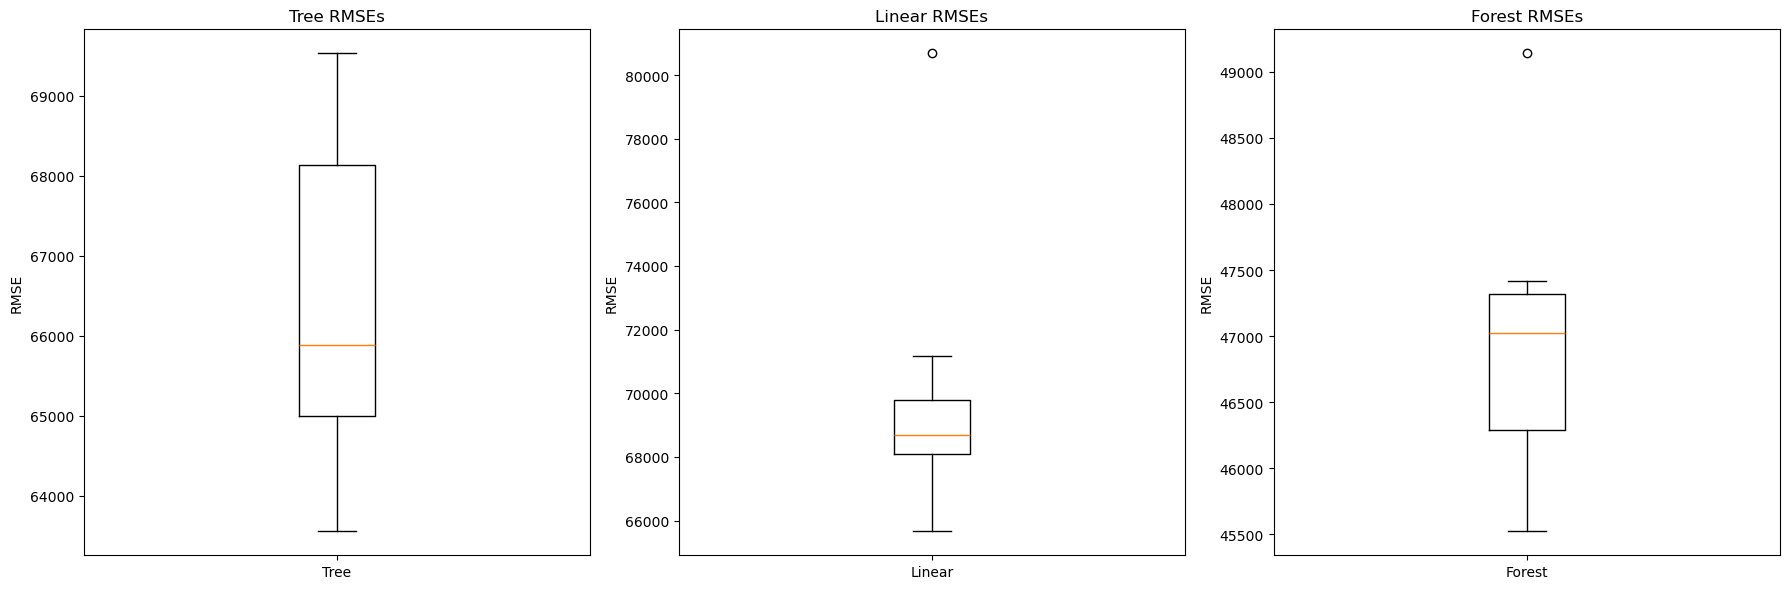

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'Tree RMSEs': tree_rmses,
    'Linear RMSEs': lin_rmses,
    'Forest RMSEs': forest_rmses
})

# Plotting
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Boxplot for Tree RMSEs
axes[0].boxplot(data['Tree RMSEs'])
axes[0].set_title('Tree RMSEs')
axes[0].set_ylabel('RMSE')
axes[0].set_xticks([1])
axes[0].set_xticklabels(['Tree'])

# Boxplot for Linear RMSEs
axes[1].boxplot(data['Linear RMSEs'])
axes[1].set_title('Linear RMSEs')
axes[1].set_ylabel('RMSE')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Linear'])

# Boxplot for Forest RMSEs
axes[2].boxplot(data['Forest RMSEs'])
axes[2].set_title('Forest RMSEs')
axes[2].set_ylabel('RMSE')
axes[2].set_xticks([1])
axes[2].set_xticklabels(['Forest'])

# Show the plot
plt.tight_layout()
plt.show()

**Compare this RMSE measured using cross-validation**

In [26]:
# Fit the Random Forest Regressor model on the entire training dataset
forest_reg.fit(strat_housing, strat_housing_labels)

# Make predictions on the training data using the trained Random Forest Regressor
strat_housing_predictions = forest_reg.predict(strat_housing)

# Calculate the Root Mean Squared Error (RMSE) of the predictions
forest_rmse = np.sqrt(mean_squared_error(strat_housing_labels, strat_housing_predictions))

In [27]:
print("Random Forest RMSE on training data:", forest_rmse)

Random Forest RMSE on training data: 17521.565358779884


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Create a full pipeline that includes the preprocessing steps and the Random Forest Regressor
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])

# Define the grid of hyperparameters to search
param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10], # Number of clusters for geographical similarity
     'random_forest__max_features': [4, 6, 8]},  # Number of features to consider at each split
    {'preprocessing__geo__n_clusters': [10, 15],  # Additional values for number of clusters
     'random_forest__max_features': [6, 8, 10]},  # Additional values for number of features
]

# Create a GridSearchCV object
# 'cv=3' specifies 3-fold cross-validation
# 'scoring="neg_root_mean_squared_error"' specifies that we want to minimize the RMSE
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')

# Perform the grid search on the training data
grid_search.fit(strat_housing, strat_housing_labels)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"


In [29]:
#Shows part of the output of get_params().keys()
print(str(full_pipeline.get_params().keys())[:1000] + "...")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__force_int_remainder_cols', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__transform_input', 'preprocessing__remainder__verbose', 'preprocessing__remainder__simpleimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__simpleimputer__add_indicator', 'preprocessing__remainder__simpleimputer__copy', 'preprocessing__remainder__simpleimputer__fill_value', 'preprocessing__remainder__simpleimputer__keep_empty_features', 'preprocessing__remainder__simpleimputer__missing_values', 'preprocessing__remainder__simpleimputer__strategy', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 

In [30]:
# Get the best hyperparameters found by the grid search
print("Best parameters:", grid_search.best_params_)

# Get the best RMSE score (negative RMSE) found by the grid search
print("Best RMSE score:", -grid_search.best_score_)

Best parameters: {'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}
Best RMSE score: 43616.07551705611


In [31]:
#displays overall pipeline
grid_search.best_estimator_

,steps,"[('preprocessing', ...), ('random_forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# extra code – these few lines of code just make the DataFrame look nicer
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,6,43007,43683,44158,43616
13,15,8,43697,44011,44819,44176
7,10,6,43710,44133,45227,44356
9,10,6,43710,44133,45227,44356
6,10,4,43798,44233,45100,44377


## Randomized Search:

In [33]:

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


# Define the distribution of hyperparameters to sample from
param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50), #samples integer values between 3 and 49 for the number of clusters
                  'random_forest__max_features': randint(low=2, high=20)} #samples integer values between 2 and 19 for the number of features

# Create a RandomizedSearchCV object
# 'full_pipeline' is the pipeline that includes preprocessing and the model
# 'param_distributions' specifies the distributions to sample hyperparameters from
# 'n_iter=10' specifies the number of parameter settings that are sampled
# 'cv=3' specifies 3-fold cross-validation
# 'scoring="neg_root_mean_squared_error"' specifies that we want to minimize the RMSE
# 'random_state=42' ensures reproducibility of the random sampling
rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42)

# Perform the randomized search on the training data
rnd_search.fit(strat_housing, strat_housing_labels)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'preprocessing__geo__n_clusters': <scipy.stats....001A2E4170490>, 'random_forest__max_features': <scipy.stats....001A2E2F20950>}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [34]:
#  displays the random search results
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,41226,42385,42712,42108
8,32,7,41374,42579,43230,42394
0,41,16,42397,42640,43175,42738
5,42,4,41761,43348,43690,42933
2,23,8,42421,43138,43585,43048


Plots of the probability mass functions (for discrete variables), and probability density functions (for continuous variables)

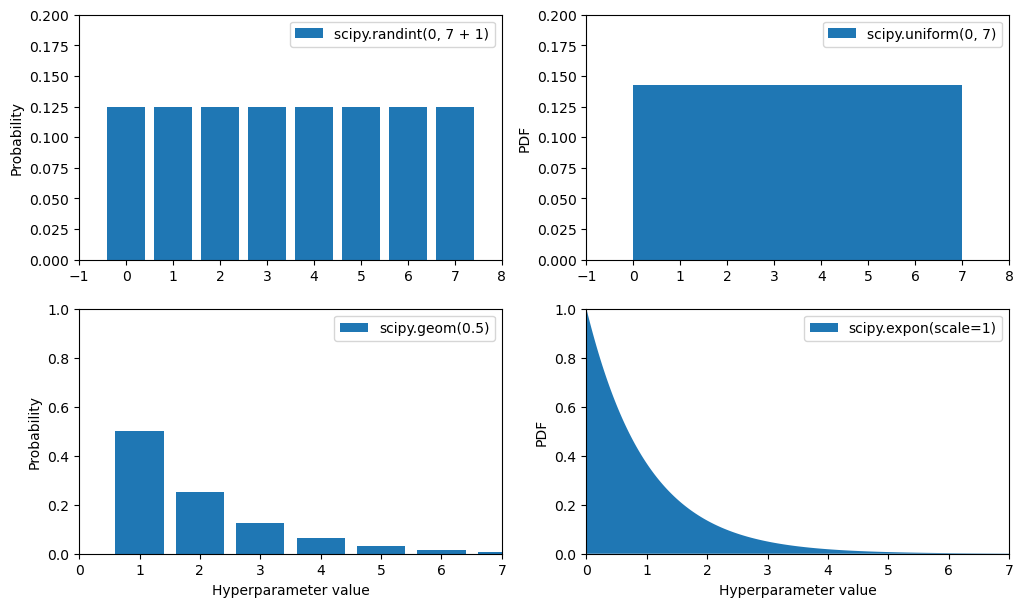

In [35]:
# extra code – plots a few distributions you can use in randomized search

from scipy.stats import randint, uniform, geom, expon

xs1 = np.arange(0, 7 + 1)
randint_distrib = randint(0, 7 + 1).pmf(xs1)

xs2 = np.linspace(0, 7, 500)
uniform_distrib = uniform(0, 7).pdf(xs2)

xs3 = np.arange(0, 7 + 1)
geom_distrib = geom(0.5).pmf(xs3)

xs4 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.bar(xs1, randint_distrib, label="scipy.randint(0, 7 + 1)")
plt.ylabel("Probability")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 2)
plt.fill_between(xs2, uniform_distrib, label="scipy.uniform(0, 7)")
plt.ylabel("PDF")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 3)
plt.bar(xs3, geom_distrib, label="scipy.geom(0.5)")
plt.xlabel("Hyperparameter value")
plt.ylabel("Probability")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 4)
plt.fill_between(xs4, expon_distrib, label="scipy.expon(scale=1)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.show()

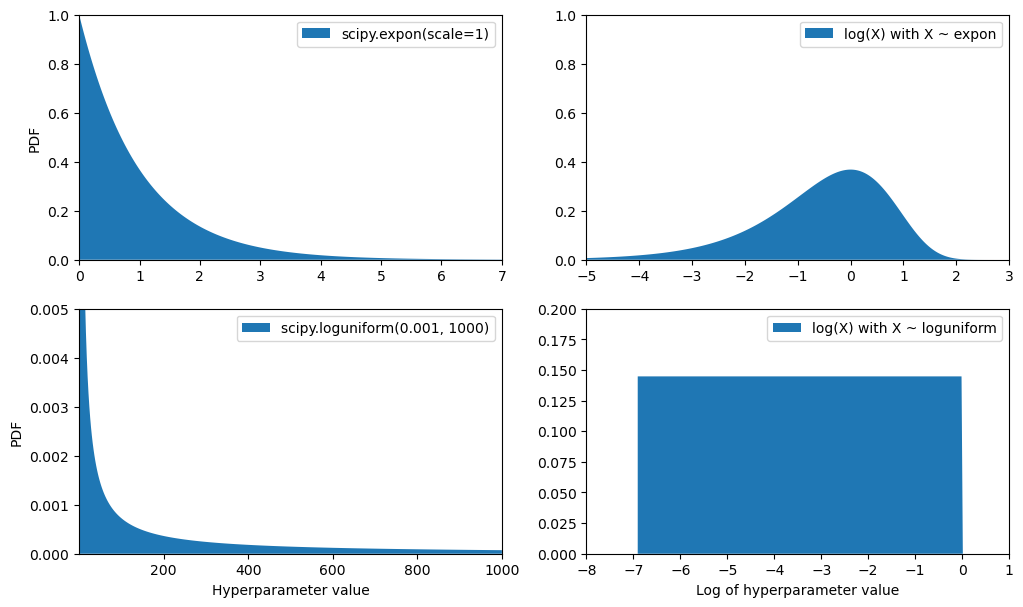

In [36]:
#Shows the difference between expon and loguniform

from scipy.stats import loguniform

xs1 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs1)

log_xs2 = np.linspace(-5, 3, 500)
log_expon_distrib = np.exp(log_xs2 - np.exp(log_xs2))

xs3 = np.linspace(0.001, 1000, 500)
loguniform_distrib = loguniform(0.001, 1000).pdf(xs3)

log_xs4 = np.linspace(np.log(0.001), np.log(1000), 500)
log_loguniform_distrib = uniform(np.log(0.001), np.log(1000)).pdf(log_xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.fill_between(xs1, expon_distrib,
                 label="scipy.expon(scale=1)")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 2)
plt.fill_between(log_xs2, log_expon_distrib,
                 label="log(X) with X ~ expon")
plt.legend()
plt.axis([-5, 3, 0, 1])

plt.subplot(2, 2, 3)
plt.fill_between(xs3, loguniform_distrib,
                 label="scipy.loguniform(0.001, 1000)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0.001, 1000, 0, 0.005])

plt.subplot(2, 2, 4)
plt.fill_between(log_xs4, log_loguniform_distrib,
                 label="log(X) with X ~ loguniform")
plt.xlabel("Log of hyperparameter value")
plt.legend()
plt.axis([-8, 1, 0, 0.2])

plt.show()

**Analyze the Best Models and Their Errors**

In [37]:
# Retrieve the best model found by the Randomized Search
# 'rnd_search.best_estimator_' includes both the preprocessing pipeline and the Random Forest Regressor
final_model = rnd_search.best_estimator_  # includes preprocessing

# Extract the feature importances from the Random Forest Regressor
# 'feature_importances_' is an attribute of the Random Forest Regressor that provides the importance of each feature
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.06, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.01, 0.02,
       0.04, 0.01, 0.  , 0.02, 0.01, 0.01, 0.  , 0.02, 0.01, 0.  , 0.01,
       0.01, 0.01, 0.01, 0.02, 0.02, 0.01, 0.01, 0.01, 0.02, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01, 0.01, 0.01, 0.02,
       0.01, 0.01, 0.01, 0.01, 0.02, 0.02, 0.01, 0.01, 0.01, 0.  , 0.08,
       0.  , 0.  , 0.  , 0.01])

In [38]:
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
           reverse=True)

[(np.float64(0.18883049114642353), 'log__median_income'),
 (np.float64(0.07550690165952419), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.06427087748676082), 'bedrooms__ratio'),
 (np.float64(0.0521695509969851), 'rooms_per_house__ratio'),
 (np.float64(0.04664258696240615), 'people_per_house__ratio'),
 (np.float64(0.04244311259449021), 'geo__Cluster 3 similarity'),
 (np.float64(0.02329106317954673), 'geo__Cluster 17 similarity'),
 (np.float64(0.022649484211911694), 'geo__Cluster 18 similarity'),
 (np.float64(0.02197243576680579), 'geo__Cluster 22 similarity'),
 (np.float64(0.01881537204558837), 'geo__Cluster 40 similarity'),
 (np.float64(0.017669986767360032), 'geo__Cluster 10 similarity'),
 (np.float64(0.01754694953848625), 'geo__Cluster 35 similarity'),
 (np.float64(0.017274903717750808), 'geo__Cluster 41 similarity'),
 (np.float64(0.0160556631074201), 'geo__Cluster 6 similarity'),
 (np.float64(0.015811758952117744), 'geo__Cluster 2 similarity'),
 (np.float64(0.01477755940463033), '

In [39]:
# Separate the features and the target variable in the test set
# Drop the target variable 'median_house_value' to create the feature matrix 'X_test'
X_test = strat_test_set.drop("median_house_value", axis=1)

# Copy the target variable 'median_house_value' to create the label vector 'y_test'
y_test = strat_test_set["median_house_value"].copy()

# Use the trained final model to make predictions on the test data
final_predictions = final_model.predict(X_test)


In [40]:
# Display the first few predicted values
print("Predicted values:", final_predictions[:5])

# Display the corresponding actual values
print("Actual values:", y_test[:5].values)

Predicted values: [415116.29 214128.   353359.2  331427.   270297.02]
Actual values: [397700. 202900. 310000. 314300. 187500.]


In [41]:
# Calculate the Root Mean Squared Error (RMSE) of the final model's predictions on the test set
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
print(final_rmse)

41556.053474456494


We can compute a 95% confidence interval for the test RMSE:

In [42]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([39415.11928419, 43591.96637635])

##Save the Model for the Launch (Optional)

In [43]:
import joblib

# Save the trained model to a file
# 'final_model' is the trained model, which includes the preprocessing pipeline and the Random Forest Regressor
# The model is saved to a file named "my_california_housing_model.pkl"
joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

In [44]:
import joblib

############ Following code will be required to run your model in python ##########
# extra code – excluded for conciseness
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

# Note that you will still need your pipelines to transform your nea real world data.
def column_ratio(X):
      return X[:, [0]] / X[:, [1]]

#class ClusterSimilarity(BaseEstimator, TransformerMixin):
#    [...]

###################################################################################

# Load the trained model from the file
# This allows the model to be used without retraining
final_model_reloaded = joblib.load("my_california_housing_model.pkl")

# Use the loaded model to make predictions on new data
# 'new_data' represents new housing data for which we want to make predictions
new_data = housing.iloc[:5]  # pretend these are new districts
predictions = final_model_reloaded.predict(new_data)

In [45]:
predictions

array([434691.11, 375226.06, 381995.1 , 341939.  , 322273.  ])